(Text(0.5, 1.0, 'redcell hough circles'), ([], []), ([], []))

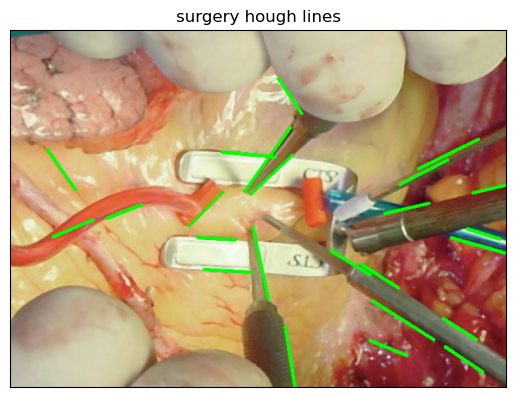

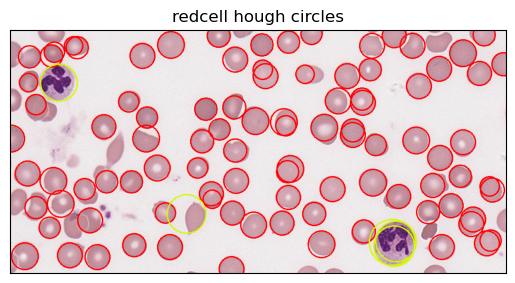

In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

img = cv.imread('surgery.jpeg')
img = cv.medianBlur(img, 5)
edges = cv.Canny(img, 50, 200, None, 3)
lines = cv.HoughLinesP(edges, 1, np.pi / 100, 30, None, minLineLength=47, maxLineGap=5)
for i in range(0, len(lines)):
    l = lines[i][0]
    cv.line(img, (l[0], l[1]), (l[2], l[3]), (0, 255, 0), 3, cv.LINE_4)

img=cv.cvtColor(img,cv.COLOR_RGB2BGR)
plt.figure(),plt.imshow(img)
plt.title('surgery hough lines'),plt.xticks([]),plt.yticks([])

img1 = cv.imread('redcell.jpeg')
gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
gray=cv.medianBlur(gray,5)

# Find the Edge of cells
circles_red = cv.HoughCircles(gray, cv.HOUGH_GRADIENT, 1, img1.shape[0]/64, param1=200, param2=20, minRadius=20, maxRadius=30)
circles_w = cv.HoughCircles(gray, cv.HOUGH_GRADIENT, 1, img1.shape[0]/64, param1=225 , param2=21 , minRadius=40, maxRadius=52)

# Draw red circles

circles_red = np.uint16(np.around(circles_red))
for i in circles_red[0, :]:
    cv.circle(img1, (i[0], i[1]), i[2], (0, 0, 255), 2)

# Draw withe circles
circles_w = np.uint16(np.around(circles_w))
for i in circles_w[0, :]:
    cv.circle(img1, (i[0], i[1]), i[2], (0, 250, 210), 2)

img1=cv.cvtColor(img1,cv.COLOR_RGB2BGR)
plt.figure(),plt.imshow(img1)
plt.title('redcell hough circles'),plt.xticks([]),plt.yticks([])
